<a href="https://colab.research.google.com/github/nivedithajnambiar-bit/student-performance-analysis/blob/main/Task4_Responsible_AI_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 4: Responsible AI & Model Interpretation
This notebook demonstrates feature importance, bias analysis, and mitigation using the Titanic dataset.

In [1]:
!pip -q install pandas scikit-learn matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

In [3]:
titanic=fetch_openml(name='titanic',version=1,as_frame=True)
df=titanic.frame[['pclass','age','sibsp','parch','fare','sex','survived']].dropna()
df['sex']=df['sex'].map({'male':0,'female':1})
X=df.drop('survived',axis=1)
y=df['survived'].astype(int)
print(df.head())

   pclass      age  sibsp  parch      fare sex survived
0       1  29.0000      0      0  211.3375   1        1
1       1   0.9167      1      2  151.5500   0        1
2       1   2.0000      1      2  151.5500   1        0
3       1  30.0000      1      2  151.5500   0        0
4       1  25.0000      1      2  151.5500   1        0


In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=RandomForestClassifier(random_state=42)
model.fit(X_train,y_train)
print("Accuracy:",model.score(X_test,y_test))

Accuracy: 0.7559808612440191


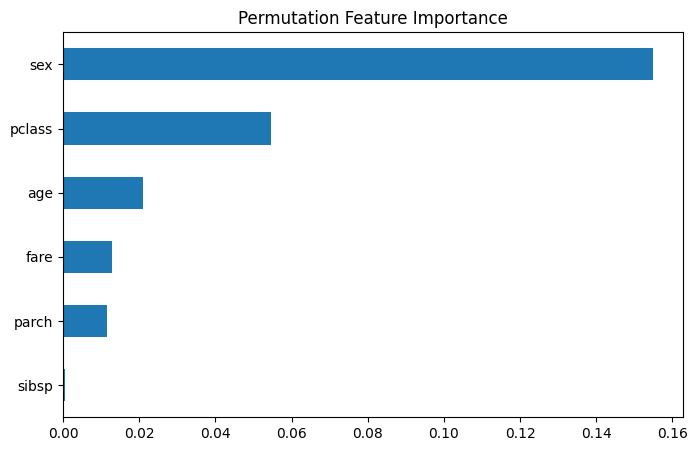

In [5]:
importance=permutation_importance(model,X_test,y_test,n_repeats=10,random_state=42)
fi=pd.Series(importance.importances_mean,index=X.columns).sort_values()
plt.figure(figsize=(8,5))
fi.plot(kind='barh')
plt.title('Permutation Feature Importance')
plt.show()

In [6]:
male_acc=model.score(X_test[X_test['sex']==0],y_test[X_test['sex']==0])
female_acc=model.score(X_test[X_test['sex']==1],y_test[X_test['sex']==1])
print('Male Accuracy:',male_acc)
print('Female Accuracy:',female_acc)
print('\nMitigation Strategies:')
print('1. Use balanced datasets')
print('2. Monitor fairness metrics')
print('3. Audit predictions regularly')
print('4. Reduce dependence on sensitive attributes')
print('5. Retrain with updated data')

Male Accuracy: 0.7874015748031497
Female Accuracy: 0.7073170731707317

Mitigation Strategies:
1. Use balanced datasets
2. Monitor fairness metrics
3. Audit predictions regularly
4. Reduce dependence on sensitive attributes
5. Retrain with updated data
